# Preprossing and initial checks


In [1]:
import pandas as pd

## Loading the Training and Test Data into DataFrames

Here, we will use the CSV file generated in the previous task as the training dataset `shipment_bookings_train.csv`. It includes the shipment records for all carriers that opted-in for tracking, and each of these shipment records contains a groundtruth column, `on_time_estimation`, which indicates whether the shipment was delivered on time or not.

This dataset will be essential for building and validating predictive models in the next steps.

The test dataset is located in the `new_shipment_bookings.csv` file, and our goal is to predict for each record whether it will be delivered on time or not.

In [2]:
train_df = pd.read_csv('./data/shipment_bookings_train.csv')
test_df = pd.read_csv('./data/new_shipment_bookings.csv')

## The Test Data Has an Extra Column That Will Be Ignored in the Next Steps

`SHIPPER_ID` is a column that exists only in the test data, and it will not serve any purpose in training the predictive model. Therefore, we will ignore this column in the subsequent steps.

In [3]:
# Compare two lists and find differences
diff_in_train = list(set(train_df.columns) - set(test_df.columns))
diff_in_test = list(set(test_df.columns) - set(train_df.columns))

# Print the differences
print("Items in train_df but not in test_df:", diff_in_train)
print("Items in test_df but not in train_df:", diff_in_test)

Items in train_df but not in test_df: ['on_time_estimation']
Items in test_df but not in train_df: ['SHIPPER_ID']


## Checking the Sizes of the Training and Test Sets

Before moving forward, we need to confirm the sizes of the training and test datasets to ensure they are properly prepared for model training and prediction.

We observe that the dataset is imbalanced, with the number of positive samples being 2.6 times higher than the number of negative samples. This imbalance will be addressed during model training by applying oversampling techniques to increase the representation of negative samples.

In [4]:
# Quick check on the number of rows in each dataframe
train_row_count = len(train_df)
train_positive_samples_count = train_df['on_time_estimation'].sum()
train_negative_samples_count = train_row_count - train_positive_samples_count
test_row_count = len(test_df)

print(f"Number of train data records: {train_row_count}")
print(f"\tNumber of positive samples in the training data: {train_positive_samples_count}")
print(f"\tNumber of negative samples in the training data: {train_negative_samples_count}")
print(f"\tPositives/Negatives ratio = {(train_positive_samples_count/train_negative_samples_count):.2f}")
print(f"\nNumber of test data booking records: {test_row_count}")

Number of train data records: 3082
	Number of positive samples in the training data: 2230
	Number of negative samples in the training data: 852
	Positives/Negatives ratio = 2.62

Number of test data booking records: 1000


### Filling the Null Postcode Values in the Test Dataset

As we did in the previous task, we will utilize the [OpenCageData API](https://api.opencagedata.com) to fill the missing postcode values in the test dataset.

We will use the same functions, `get_postcode` and `fill_missing_postcodes`, that were implemented in the earlier task to ensure consistency.

Note: The training set has already been processed by these functions in the previous task, so only the test dataset requires this step.

In [5]:
import requests

# Function to get postcode using latitude and longitude
def get_postcode(lat, lon):
    try:
        url = f"https://api.opencagedata.com/geocode/v1/json?q={lat}%2C{lon}&key=44622e33fb6046ab843ba44739d5ecab"
        response = requests.get(url)
        data = response.json()
        if response.status_code == 200 and len(data['results']) > 0:
            if 'postcode' in data['results'][0]['components']:
                return data['results'][0]['components']['postcode']
            elif '_normalized_city' in data['results'][0]['components']:
                return data['results'][0]['components']['country'].upper()
            else:
                return 'UNKNOWN'
        else:
            print(f"Error fetching postcode for lat={lat}, lon={lon}")
            return 'UNKNOWN'
    except Exception as e:
        print(f"Exception occurred: {e}")
        return 'UNKNOWN'

# Fill missing postcodes in the DataFrame
def fill_missing_postcodes(df, lat_col, lon_col, postcode_col):
    for idx, row in df[df[postcode_col].isna()].iterrows():
        lat = row[lat_col]
        lon = row[lon_col]
        if pd.notna(lat) and pd.notna(lon):  # Ensure lat and lon are not missing
            postcode = get_postcode(lat, lon)
            if postcode:
                df.at[idx, postcode_col] = postcode  # Fill in the missing postcode
                print(f"Updated row {idx} with postcode {postcode}")
            else:
                print(f"Could not find postcode for row {idx}, lat {lat}, lon {lon}")
        else:
            print(f"Missing lat/lon for row {idx}")

# Apply the function to the relevant columns in the DataFrame
fill_missing_postcodes(test_df, 'FIRST_COLLECTION_LATITUDE', 'FIRST_COLLECTION_LONGITUDE', 'FIRST_COLLECTION_POST_CODE')

Updated row 608 with postcode CV23 8YS
Updated row 822 with postcode CV23 8YS


## Handling Time Zones and Datetime Conversion

Like in the previous task, we convert the string-based datetime columns into proper `datetime` objects, ensuring they are timezone-aware in UTC. This is essential for maintaining consistency across time-related operations, especially when comparing timestamps between the GPS tracking data and the shipment booking records. By enforcing UTC time, we eliminate potential issues arising from differing time zones or formats in the dataset.

We will use the same `convert_to_datetime_utc` function we used in the previous task.

In [6]:
def convert_to_datetime_utc(df_list, time_columns):
    """
    Convert the datetime columns from string to timezone-aware datetime objects in UTC 
    for each DataFrame in the df_list.

    Parameters:
    df_list (list): List of DataFrames to be processed (e.g. [train_df, test_df])
    time_columns (list): List of columns that need to be converted to datetime objects
    """
    for df in df_list:
        for col in time_columns:
            df[col] = pd.to_datetime(df[col], utc=True)

# Usage
time_columns = ['FIRST_COLLECTION_SCHEDULE_EARLIEST', 'FIRST_COLLECTION_SCHEDULE_LATEST', 
                'LAST_DELIVERY_SCHEDULE_EARLIEST', 'LAST_DELIVERY_SCHEDULE_LATEST']

convert_to_datetime_utc([train_df, test_df], time_columns)

## Validate GPS (Latitude and Longitude) Values

We need to ensure that latitude and longitude values fall within a reasonable range for shipments within the UK and Ireland:

* Latitude: 49 to 60
* Longitude: -10 to 2

We will use the same `check_uk_lat_lon_stats` function that was first defined in the previous task's notebook to perform this validation.

We note that all the GPS values in the test data are valid. The train data was already validated during the previous task.

In [7]:
def check_uk_lat_lon_stats(description, col_name):
    lat_range = (49, 60)      # UK latitude range
    lon_range = (-10, 2)      # UK longitude range
    
    min_value = description['min']
    max_value = description['max']
    
    if "LAT" in col_name.upper():
        if lat_range[0] <= min_value <= lat_range[1] and lat_range[0] <= max_value <= lat_range[1]:
            print(f"\t{col_name} is within the expected UK latitude range.")
        else:
            print(f"\t{col_name} has values outside the expected UK latitude range!")
    elif "LON" in col_name.upper():
        if lon_range[0] <= min_value <= lon_range[1] and lon_range[0] <= max_value <= lon_range[1]:
            print(f"\t{col_name} is within the expected UK longitude range.")
        else:
            print(f"\t{col_name} has values outside the expected UK longitude range!")

columns_to_check = ['FIRST_COLLECTION_LATITUDE', 'FIRST_COLLECTION_LONGITUDE', 
                    'LAST_DELIVERY_LATITUDE', 'LAST_DELIVERY_LONGITUDE']

print("\nValidating the range of GPS coordinates in the New Shipment bookings data, i.e. the Test data:")
for col in columns_to_check:
    desc = test_df[col].describe()
    check_uk_lat_lon_stats(desc, col)


Validating the range of GPS coordinates in the New Shipment bookings data, i.e. the Test data:
	FIRST_COLLECTION_LATITUDE is within the expected UK latitude range.
	FIRST_COLLECTION_LONGITUDE is within the expected UK longitude range.
	LAST_DELIVERY_LATITUDE is within the expected UK latitude range.
	LAST_DELIVERY_LONGITUDE is within the expected UK longitude range.


# Fix Timing Inconsistencies in Collection and Delivery Windows (if exists)

As we did in the previous task, we apply the `fix_timing` function on the test data to correct any inconsistencies between the collection or delivery time windows. This ensures that the delivery window doesn't precede the collection window, and any other timing anomalies are addressed.

In [8]:
import pandas as pd

def fix_timing(df, collection_start_col, collection_end_col, delivery_start_col, delivery_end_col, default_window_minutes=30):
    
    # Step 1: Fix collection window if it's invalid
    def fix_collection_window(row):
        if row[collection_start_col] > row[collection_end_col]:
            # Calculate the time difference in delivery window
            if row[delivery_end_col] > row[delivery_start_col]:
                time_diff = row[delivery_end_col] - row[delivery_start_col]
            else:
                # Use default window if delivery window is also invalid
                time_diff = pd.Timedelta(minutes=default_window_minutes)
            
            # Adjust the collection window based on the time difference
            row[collection_end_col] = row[collection_start_col] + time_diff
        
        return row
    
    # Step 2: Fix delivery window if it's invalid
    def fix_delivery_window(row):
        if row[delivery_start_col] > row[delivery_end_col]:
            # Use the valid collection window difference to fix delivery window
            time_diff = row[collection_end_col] - row[collection_start_col]
            row[delivery_end_col] = row[delivery_start_col] + time_diff
        
        return row

    # Step 3: Adjust the delivery window so it's always after collection window
    def shift_delivery_if_needed(row):
        if row[delivery_start_col] < row[collection_start_col]:
            # Shift the delivery window to match the collection window start
            time_diff = row[collection_start_col] - row[delivery_start_col]
            row[delivery_start_col] = row[collection_start_col]
            row[delivery_end_col] = row[delivery_end_col] + time_diff
        if row[delivery_end_col] < row[collection_end_col]:
            row[delivery_end_col] = row[collection_end_col] 
        
        return row

    # Apply the steps to the dataframe
    df = df.apply(fix_collection_window, axis=1)
    df = df.apply(fix_delivery_window, axis=1)
    df = df.apply(shift_delivery_if_needed, axis=1)

    return df

# Apply the function to the test dataframe as the traing dataframe is already fixed
test_df = fix_timing(test_df, 'FIRST_COLLECTION_SCHEDULE_EARLIEST', 'FIRST_COLLECTION_SCHEDULE_LATEST', 
                      'LAST_DELIVERY_SCHEDULE_EARLIEST', 'LAST_DELIVERY_SCHEDULE_LATEST')

# Feature Extraction and Engineering

Now, after pre-processing the data, we are ready to design, extract, and prepare features for training. This crucial step will allow us to transform the raw data into a more structured and useful format, enabling machine learning models to make accurate predictions.

In the next code block, we will appy the following 6 steps to extract features and scale them.


1. **Distance Calculation**: We compute the distance between the first collection and the last delivery locations based on their latitude and longitude.

2. **Feature Selection**: Key features such as carrier information, vehicle details, postcodes, and timing data are selected for the model.

3. **Postcode Engineering**: The postcodes are simplified by extracting their outward codes (the first part), making the feature more useful.

4. **Time Windows Durations**: We create new features by calculating the duration between the earliest and latest collection and delivery times.

5. **Encoding Categorical Features**: Categorical features like carrier ID, vehicle type, and postcodes are transformed into numerical format using one-hot encoding.

6. **Standardization**: Numerical features such as distance and time durations are standardized to ensure consistency in the model.


In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from geopy.distance import geodesic
import pandas as pd

# Function to calculate the distance in miles between two sets of latitude and longitude coordinates
def calculate_distance(lat1, lon1, lat2, lon2):
    return geodesic((lat1, lon1), (lat2, lon2)).miles

def extract_outward_code(postcode):
    if ' ' in postcode:
        return postcode.split()[0]
    else:
        return postcode

# Helper function to create time-based features, including hours, days, and duration windows
def create_time_features(df):
    # Extract the hour (0-23) and day of the week (0 = Monday, 6 = Sunday)
    df['collection_earliest_hour'] = df['FIRST_COLLECTION_SCHEDULE_EARLIEST'].dt.hour
    df['collection_latest_hour'] = df['FIRST_COLLECTION_SCHEDULE_LATEST'].dt.hour
    df['delivery_earliest_hour'] = df['LAST_DELIVERY_SCHEDULE_EARLIEST'].dt.hour
    df['delivery_latest_hour'] = df['LAST_DELIVERY_SCHEDULE_LATEST'].dt.hour
    
    df['collection_day_of_week'] = df['FIRST_COLLECTION_SCHEDULE_EARLIEST'].dt.dayofweek
    df['delivery_day_of_week'] = df['LAST_DELIVERY_SCHEDULE_EARLIEST'].dt.dayofweek
    
    # Create new features for the duration of collection and delivery time windows in hours
    df['collection_window_duration'] = (df['FIRST_COLLECTION_SCHEDULE_LATEST'] - df['FIRST_COLLECTION_SCHEDULE_EARLIEST']).dt.total_seconds() / 3600
    df['delivery_window_duration'] = (df['LAST_DELIVERY_SCHEDULE_LATEST'] - df['LAST_DELIVERY_SCHEDULE_EARLIEST']).dt.total_seconds() / 3600
    
    return df

# Function to extract features, encode categorical data, and scale numerical features
def feature_extraction(input_df, encoder=None, scaler=None, is_training=True):
    """
    Extract features, encode categorical variables, and scale numerical variables.

    Parameters:
    df (DataFrame): The dataset to process (train or test).
    encoder (OneHotEncoder): The encoder to use for categorical features (fitted on training data).
    scaler (StandardScaler): The scaler to use for numerical features (fitted on training data).
    is_training (bool): If True, fit encoder and scaler; if False, just transform.
    
    Returns:
    X_encoded (DataFrame): The processed feature set ready for model input.
    encoder (OneHotEncoder): The encoder fitted on the training data.
    scaler (StandardScaler): The scaler fitted on the training data.
    """
    df = input_df.copy()  # Avoid modifying the original dataframe

    # Step 1: Calculate the distance between collection and delivery locations for each shipment
    df['start_end_distance'] = df.apply(lambda row: calculate_distance(row['FIRST_COLLECTION_LATITUDE'], 
                                                                       row['FIRST_COLLECTION_LONGITUDE'], 
                                                                       row['LAST_DELIVERY_LATITUDE'], 
                                                                       row['LAST_DELIVERY_LONGITUDE']), axis=1)
    
    # Step 2: Extract relevant time-based features
    df = create_time_features(df)
    
    # Step 3: Extract the outward code (first part of the postcode)    
    df['FIRST_COLLECTION_POST_CODE'] = df['FIRST_COLLECTION_POST_CODE'].apply(extract_outward_code)
    df['LAST_DELIVERY_POST_CODE'] = df['LAST_DELIVERY_POST_CODE'].apply(extract_outward_code)
    
    # Step 4: Categorical features that will be converted into numerical format via One-hot encoding
    categorical_features = ['CARRIER_ID', 'VEHICLE_SIZE', 'VEHICLE_BUILD_UP', 
                            'FIRST_COLLECTION_POST_CODE', 'LAST_DELIVERY_POST_CODE', 
                            'collection_day_of_week', 'delivery_day_of_week']
    
    if is_training:
        encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded_features = encoder.fit_transform(df[categorical_features])
    else:
        encoded_features = encoder.transform(df[categorical_features])
    
    encoded_features_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

    # Drop the original categorical features add their encoded version
    df_encoded = pd.concat([df.drop(categorical_features, axis=1), encoded_features_df], axis=1)
    
    # Step 5: Standardize numerical features to normalize their scale for model training
    numerical_features = ['start_end_distance',
                          'collection_window_duration', 'delivery_window_duration',
                          'collection_earliest_hour', 'collection_latest_hour', 
                          'delivery_earliest_hour', 'delivery_latest_hour']
    
    if is_training:
        scaler = StandardScaler()
        df_encoded[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])
    else:
        df_encoded[numerical_features] = scaler.transform(df_encoded[numerical_features])

    
    # Step 6: split the dataframe into features (X) and ground trugh (y) 
    feature_columns = list(numerical_features) + list(encoded_features_df.columns)
    X = df_encoded[feature_columns]

    y = None
    if is_training:
        y = df['on_time_estimation']
    
    return X, y, encoder, scaler

## Data Splitting and Handling Class Imbalance

With the features now prepared, it is time to split the data and address the class imbalance.

**Data Splitting**: The dataset is divided into training and validation sets, ensuring that model performance is evaluated on unseen data to avoid overfitting and provide a more accurate assessment.

**Handling Class Imbalance**: Since the positive samples significantly outnumber the negative ones (approximately 3:1), we apply random oversampling to balance the classes in the training set. This helps to reduce bias towards the majority class and improves the model's ability to generalize and perform well on both classes.

In [25]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

X_train_encoded, y_train, encoder, scaler = feature_extraction(train_df, is_training=True)

# Split the data into training and validation sets (80% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train_encoded, y_train, test_size=0.2, random_state=42)

# Apply random oversampling to balance the training set
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

## Running Grid Search with Model Evaluation

The following function runs a machine learning model with GridSearchCV to optimize hyperparameters and evaluate its performance on a validation set. 

### Input Parameters:
- **model**: The machine learning model to train (e.g., `RandomForestClassifier`, `XGBClassifier`, `LogisticRegression`).
- **param_grid**: A dictionary containing the hyperparameters to search over.
- **X_train, y_train**: The training dataset and corresponding labels.
- **X_val, y_val**: The validation dataset and corresponding labels.

### Steps:
1. **Grid Search for Hyperparameter Tuning**: 
   GridSearchCV is used to find the optimal hyperparameters by conducting cross-validation on the training set.
   
2. **Best Model Selection**: 
   The model with the highest cross-validation accuracy is selected and fitted to the training data.
   
3. **Model Evaluation on Validation Set**: 
   The best model is used to predict labels on the validation set, and the validation accuracy is printed.

4. **Confusion Matrix**: 
   A confusion matrix is calculated to display the breakdown of True Positives (TP), False Positives (FP), True Negatives (TN), and False Negatives (FN).

### Return:
- **best_model**: The model that achieved the highest accuracy during cross-validation.


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix

def run_model_with_grid_search(model, param_grid, X_train, y_train, X_val, y_val):
    """
    Function to run a model with GridSearchCV and evaluate it on a validation set.

    Parameters:
    - model: The machine learning model (e.g., RandomForestClassifier, XGBClassifier, LogisticRegression).
    - param_grid: Dictionary of hyperparameters to search over.
    - X_train: Training features.
    - y_train: Training labels.
    - X_val: Validation features.
    - y_val: Validation labels.
    """

    # Use GridSearchCV to find the best parameters
    grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

    # Fit the model
    grid_search.fit(X_train, y_train)

    # Get the best performing model
    best_model = grid_search.best_estimator_

    # Print the best parameters and the best accuracy
    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"\nBest accuracy during cross-validation: {grid_search.best_score_ * 100:.2f}%")

    # Evaluate on validation set
    y_val_pred = best_model.predict(X_val)

    # Calculate confusion matrix
    conf_matrix = confusion_matrix(y_val, y_val_pred)

    # Extract True Negatives, False Positives, False Negatives, and True Positives
    TN, FP, FN, TP = conf_matrix.ravel()

    # Print the confusion matrix in a more friendly format
    print("\nConfusion Matrix:")
    print(f'\tTrue Positives (TP): {TP}')
    print(f'\tFalse Positives (FP): {FP}')
    print(f'\tTrue Negatives (TN): {TN}')
    print(f'\tFalse Negatives (FN): {FN}')

    accuracy = accuracy_score(y_val, y_val_pred)
    print(f"\nValidation accuracy: {accuracy * 100:.2f}%")

    return best_model

## Logistic Regression Model as Baseline

In this step, we train a **Logistic Regression** model as our **baseline** model. Logistic Regression is commonly used as a baseline due to its simplicity and interpretability. We call the **run_model_with_grid_search** function that applies **GridSearchCV** to perform hyperparameter tuning, exploring a range of values for key parameters:

1. **C**: The regularization strength, controlling the trade-off between low training error and minimizing model complexity to avoid overfitting.
2. **penalty**: The type of regularization applied (L1 for Lasso and L2 for Ridge).
3. **solver**: The optimization algorithm used to fit the model (`liblinear` or `saga`), each suitable for different types of penalties.

We set `max_iter` to a high value to ensure model convergence, and **GridSearchCV** searches for the best combination of hyperparameters using cross-validation. The final, best-performing Logistic Regression model is stored in `best_log_reg_model`, serving as a baseline for comparison with more complex models.


In [27]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(max_iter=8000, random_state=42)

log_reg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear', 'saga'],  # Solver for optimization
}

best_log_reg_model = run_model_with_grid_search(log_reg_model, log_reg_param_grid, X_train_resampled, y_train_resampled, X_val, y_val)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


/Users/rami/.local/share/virtualenvs/digihaul-eG1dtc_M/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}

Best accuracy during cross-validation: 77.08%

Confusion Matrix:
	True Positives (TP): 322
	False Positives (FP): 82
	True Negatives (TN): 96
	False Negatives (FN): 117

Validation accuracy: 67.75%


## Moving Beyond the Baseline: Random Forest Model Exploration

After establishing **Logistic Regression** as our baseline model, we can now move towards a more advanced and robust algorithm—**Random Forest**. Random Forest is a powerful ensemble learning method that combines multiple decision trees to improve predictive performance and generalize better to unseen data. It is particularly effective for handling non-linear relationships and reducing overfitting.

**Random Forest** is a natural next step because:
- It offers a balance between bias and variance, often performing better than individual decision trees.
- It can capture complex interactions between features that a linear model like Logistic Regression might miss.
- It is resilient to overfitting, especially with the built-in **bootstrap** feature that allows random sampling with replacement.

In this step, we apply **GridSearchCV** to fine-tune the hyperparameters of the Random Forest model. These hyperparameters include:
- **n_estimators**: The number of trees in the forest.
- **max_depth**: The maximum depth of each tree.
- **min_samples_split** and **min_samples_leaf**: Control the minimum number of samples required to split an internal node or to be a leaf node, respectively.
- **bootstrap**: Whether to use bootstrapping to sample data.

By running this grid search, we aim to find the best combination of parameters to maximize performance, and the best-performing model is stored in `best_rf_model`.

**After running the best Random Forest model on the validation set, the results confirmed our intuition. Random Forest provided a notable improvement compared to the baseline Logistic Regression model. This increase in performance highlights the effectiveness of Random Forest in capturing complex relationships within the data, making it a solid choice for further exploration.**

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

best_rf_model = run_model_with_grid_search(rf_model, rf_param_grid, X_train_resampled, y_train_resampled, X_val, y_val)

Fitting 3 folds for each of 216 candidates, totalling 648 fits

Best parameters: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best accuracy during cross-validation: 87.24%

Confusion Matrix:
	True Positives (TP): 367
	False Positives (FP): 109
	True Negatives (TN): 69
	False Negatives (FN): 72

Validation accuracy: 70.66%


## Pushing Performance Further with XGBoost

After the improvement with Random Forest, we now aim to push the model's performance further using **XGBoost**. XGBoost, a more advanced boosting algorithm, is often more efficient and performs better due to its gradient boosting approach, which optimizes tree construction while controlling overfitting.

Unlike Random Forest, XGBoost includes built-in regularization, better handling of complex relationships, and is particularly well-suited for imbalanced datasets. Given these strengths, it could potentially yield higher accuracy than Random Forest, making it a strong candidate for improving model performance in this context.

In [29]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

xgb_param_grid = {
    'max_depth': [3, 5, 7],  # Test different tree depths
    'learning_rate': [0.01, 0.1],  # Test different learning rates
    'n_estimators': [100, 500, 1000],  # Test different number of trees
    'subsample': [0.7, 0.9],  # Test different subsample ratios
    'colsample_bytree': [0.7, 1.0],  # Test different feature sampling ratios
    'min_child_weight': [1, 3]  # Test different minimum child weights
}

best_xgb_model = run_model_with_grid_search(xgb_model, xgb_param_grid, X_train_resampled, y_train_resampled, X_val, y_val)

Fitting 3 folds for each of 144 candidates, totalling 432 fits


/Users/rami/.local/share/virtualenvs/digihaul-eG1dtc_M/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 1000, 'subsample': 0.9}

Best accuracy during cross-validation: 85.62%

Confusion Matrix:
	True Positives (TP): 359
	False Positives (FP): 94
	True Negatives (TN): 84
	False Negatives (FN): 80

Validation accuracy: 71.80%


## XGBoost Results and Feature Importance

After training the XGBoost model, we observed a **Validation accuracy of 71.80%**, slightly outperforming the Random Forest model, which had an accuracy of 70.66%. While the improvement is not dramatic, it reinforces the ability of XGBoost to handle complex feature interactions and provide robust performance with carefully tuned hyperparameters.

Given these results, we will proceed with XGBoost as our prediction model for the test data. To ensure future usability, especially for production deployment, we will save the model for later use.

In [30]:
import os

# Ensure the directory exists
os.makedirs('./models', exist_ok=True)

best_xgb_model.save_model('./models/best_xgb_model.json')

### Follow-up: Feature Importance Analysis

Understanding which features contribute most to the model’s performance can offer valuable insights into the factors that influence shipment delays. In the code that follows, we analyze the **feature importances** based on the XGBoost model.

Key steps include:
- Extracting the feature importances from the trained XGBoost model (`best_xgb_model`).
- Sorting the feature importances in descending order to identify the most significant features.
- Visualizing the top 10 features that have the highest impact on model predictions.

This allows us to interpret which features, such as distance, vehicle size, or scheduling windows, are the strongest predictors of delays.

The feature importance plot below shows the top features, providing a better understanding of the model’s decision-making process:

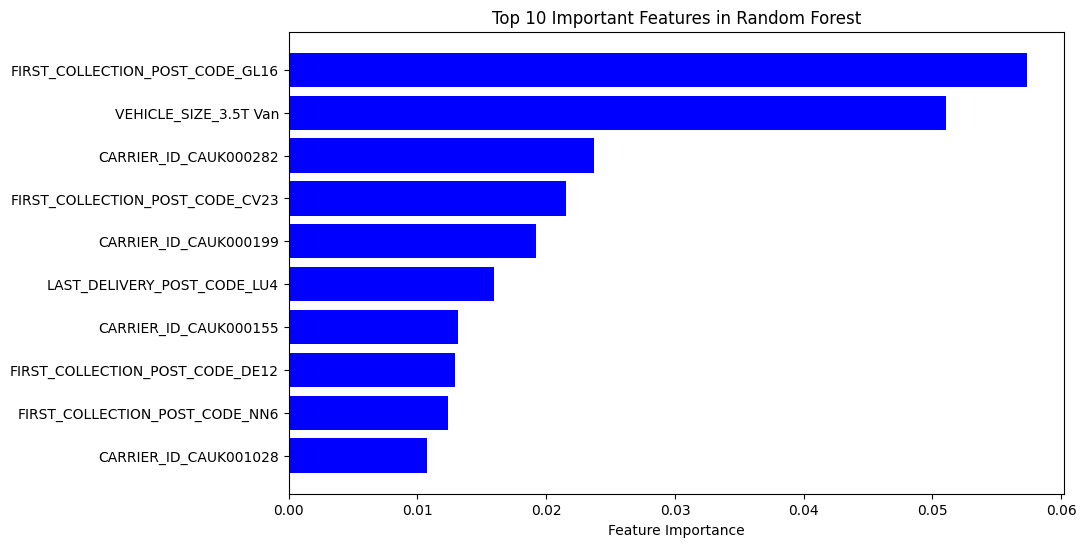

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'best_model' is your trained Random Forest model
# Get feature importances
feature_importances = best_xgb_model.feature_importances_

# Get the names of the features (you should already have them from X_train)
feature_names = X_train.columns

# Sort the feature importances and corresponding feature names
sorted_idx = np.argsort(feature_importances)[::-1]  # Sort in descending order
sorted_feature_importances = feature_importances[sorted_idx]
sorted_feature_names = feature_names[sorted_idx]

# Display top 10 features
top_n = 10  # Change this to the number of top features you want to display
top_feature_importances = sorted_feature_importances[:top_n]
top_feature_names = sorted_feature_names[:top_n]

# Plot top N feature importance
plt.figure(figsize=(10, 6))
plt.barh(top_feature_names, top_feature_importances, color='b', align='center')
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Important Features in Random Forest")
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

## Top Feature Insights

The top two features that significantly influence the model's predictions are:

1. **FIRST_COLLECTION_POST_CODE_GL16** (importance score: 6%): This suggests that the geographic location of the first collection point plays a critical role in determining delivery performance. Regional factors such as infrastructure, distance, or local logistical challenges might affect the efficiency and speed of deliveries from this area.

2. **VEHICLE_SIZE_3.5T Van** (importance score: 5%): This feature highlights the importance of vehicle size in predicting shipment delays. The 3.5T van likely affects delivery timing due to factors such as vehicle load capacity, availability, or its specific usage patterns in certain routes or regions.

Overall, the top 10 features reveal that location data (postcodes), specific carriers, and vehicle types are key drivers in the automatic decision-making process for estimating delivery time, providing a strong basis for understanding shipment delays.

## Prediction on the Test Dataset
After conducting multiple experiments, we determined that the XGBoost model delivers the best performance. Now, it is time to use this model to make predictions on the test dataset.

### Feature Extraction for Test Data
To ensure consistency, we will extract features from the test data using the **feature_extraction** function, exactly as we did for the training dataset. This ensures that both datasets are treated identically, preventing any discrepancies during the prediction phase.

In [32]:
X_new, _, _, _ = feature_extraction(test_df, encoder=encoder, scaler=scaler, is_training=False)

# Load the trained XGBoost model (assuming it was saved earlier, otherwise you can directly use bst from the training script)
y_pred_new = best_xgb_model.predict_proba(X_new)[:, 1]  # Get probabilities for the positive class (1 = on-time)

# Convert probabilities to delay likelihood (1 = delayed, 0 = on-time)
# Since in the training set, '0' corresponds to 'delayed', probabilities closer to 0 indicate a higher likelihood of delay.
test_df['delay_likelihood'] = 1 - y_pred_new

# Sort shipments by delay likelihood (optional, for better readability)
test_df.sort_values(by='delay_likelihood', ascending=True, inplace=True)

# Output results to review
res = test_df[['SHIPMENT_NUMBER', 'delay_likelihood']]

## Likelihood of delay for the test dataset

After making predictions on the test dataset, we analyze the distribution of shipments based on their predicted delay likelihood.

### Key Metrics:
- **Shipments with Delay Likelihood > 0.5 (Delay likely)**: We count how many shipments are predicted to have a delay probability greater than 50%, indicating that these shipments are likely to be delayed.
- **Shipments with Delay Likelihood ≤ 0.5 (Delay unlikely)**: We also count how many shipments have a delay probability less than or equal to 50%, suggesting that these are likely to be delivered on time.

Finally, we calculate the overall **delay likelihood** in the new test dataset, expressed as a percentage, based on the proportion of shipments predicted to have a delay likelihood greater than 0.5.


In [33]:
# Count how many shipments have delay likelihood > 0.5 (delay likely)
delay_likely_count = (res['delay_likelihood'] > 0.5).sum()

# Count how many shipments have delay likelihood <= 0.5 (delay unlikely)
delay_unlikely_count = (res['delay_likelihood'] <= 0.5).sum()

# Print the counts
print(f'Shipments with delay likelihood > 0.5 (Delay likely): {delay_likely_count}')
print(f'Shipments with delay likelihood <= 0.5 (Delay unlikely): {delay_unlikely_count}')

delay_likelihood = 100 * delay_likely_count/(delay_likely_count+delay_unlikely_count)
print(f'\nDelay likelihood in new data: {delay_likelihood}%')

Shipments with delay likelihood > 0.5 (Delay likely): 265
Shipments with delay likelihood <= 0.5 (Delay unlikely): 735

Delay likelihood in new data: 26.5%


# Conclusion

This notebook was developed to address the second question in the assignment: **Predict the likelihood of delay for the list of shipments in the "New_bookings.csv" dataset**. Through the application of a rigorous machine learning pipeline, we were able to build, evaluate, and select the best-performing model to provide reliable predictions on new shipment data.

### Process Summary
1. **Data Preparation**: 
   We carefully pre-processed both the training and test datasets by handling missing values, encoding categorical variables, and standardizing numerical features to ensure model consistency and performance.

2. **Feature Engineering**: 
   We engineered relevant features, including the calculation of geographical distances between collection and delivery locations and the creation of features to capture important temporal, positional, other details for each shipment.

3. **Model Selection**:
   We initially trained and evaluated multiple models including Logistic Regression, Random Forest, and XGBoost. After tuning hyperparameters using `GridSearchCV`, we selected XGBoost as the best-performing model with a validation accuracy of 71.80%, outperforming Random Forest and Logistic Regression.

4. **Prediction on Test Data**:
   The XGBoost model was used to predict the likelihood of delay for the shipments in the "New_bookings.csv" dataset. The results were summarised, and we identified how many shipments were likely to experience delays based on a delay likelihood threshold of 0.5.

5. **Final Results**:
   - Shipments with delay likelihood > 0.5 (Delay likely): **265**
   - Shipments with delay likelihood <= 0.5 (Delay unlikely): **735**
   - **Overall Delay Likelihood: 26.5%**

### Key Takeaways:
The analysis identified that certain features such as vehicle size and specific postal codes played a key role in determining the likelihood of delay. The use of XGBoost, with its ability to model complex interactions, was critical to achieving a strong predictive performance.

This notebook successfully provided a robust solution to predict shipment delays, demonstrating the effective application of machine learning to logistics challenges. The results are ready to be deployed in production to assist in proactive shipment delay management.


# Suggestions for Potential Improvements

While the current model performs well in predicting the likelihood of shipment delays, several external factors can be incorporated to further enhance its predictive power. Here are some potential improvements:

### 1. Incorporate Weather Data
Weather conditions can significantly impact transportation and delivery times. By using a **weather API**, we can fetch weather data corresponding to the shipment's collection and delivery dates. Factors such as heavy rain, snow, or storms could cause delays. A suitable API for this is the [OpenWeather API](https://openweathermap.org/api), which provides current and forecasted weather data for any location. By incorporating weather status as a feature, the model could be trained to account for weather-related disruptions.

### 2. Leverage Traffic Data
Real-time traffic conditions between the collection and delivery locations could provide valuable insights into shipment delays. Integrating a **traffic API** such as the [Google Maps Traffic API](https://outscraper.com/google-maps-traffic-api/) could give real-time or historical traffic data, including road congestion, speed limits, and estimated travel times. This would allow the model to better estimate shipment delivery times based on the current road conditions.

### Conclusion
By introducing these additional features, the model could become even more robust and capable of accounting for real-world conditions that affect shipment delays. This would allow for more precise predictions and ultimately help in optimizing logistics and reducing delays.